# **MSDS-696 Data Science Practicum 2 Mutli-Class Infrastructure Damage Classification using Remote Aerial Sensing**
## Notebook 3 — Base CNN Model with Full pipeline
`Author: Chennakeshava Akhil Pillalamarri`  
`Regis University`

This notebook picks up directly from the previous notebook. After trying five separate strategies that all failed to produce any minority class detection, this notebook combines everything together, Focal Loss, Balanced Batch Generator, and Macro F1 monitoring into a single pipeline.

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, regularizers, backend
from tensorflow.keras.layers import Add, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
base_path        = r"C:\Users\kesha\Desktop\MSDS-696_DSP-2"
preprocessed_dir = os.path.join(base_path, "preprocessed_dataset")
train_dir        = os.path.join(preprocessed_dir, "train")
val_dir          = os.path.join(preprocessed_dir, "validation")
test_dir         = os.path.join(preprocessed_dir, "test")

os.chdir(base_path)
print(os.getcwd())

C:\Users\kesha\Desktop\MSDS-696_DSP-2


In [3]:
for split_name, split_dir in [("train", train_dir),
                               ("validation", val_dir),
                               ("test", test_dir)]:
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(os.listdir(os.path.join(split_dir, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("---")

train Intact 6542
train Major_Damage 4284
train Structural_Failure 11132
train total: 21958
---
validation Intact 710
validation Major_Damage 585
validation Structural_Failure 1265
validation total: 2560
---
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
---


In [4]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)
print("Train images     :", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Test images      :", test_generator.samples)

Found 21958 images belonging to 3 classes.
Found 2560 images belonging to 3 classes.
Found 1049 images belonging to 3 classes.
{'Intact': 0, 'Major_Damage': 1, 'Structural_Failure': 2}
Train images     : 21958
Validation images: 2560
Test images      : 1049


In [6]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.1188219708549882, 1: 1.7085278555866792, 2: 0.6575038926817582}


In [7]:
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow(1 - y_pred, gamma)
        fl     = weight * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=1))
    return focal_loss_fn

def macro_f1(y_true, y_pred):
    y_true    = tf.cast(y_true, tf.float32)
    y_pred    = tf.cast(tf.round(y_pred), tf.float32)
    f1_scores = []
    for i in range(3):
        tp        = K.sum(y_true[:, i] * y_pred[:, i])
        fp        = K.sum((1 - y_true[:, i]) * y_pred[:, i])
        fn        = K.sum(y_true[:, i] * (1 - y_pred[:, i]))
        precision = tp / (tp + fp + K.epsilon())
        recall    = tp / (tp + fn + K.epsilon())
        f1        = 2 * precision * recall / (precision + recall + K.epsilon())
        f1_scores.append(f1)
    return tf.reduce_mean(tf.stack(f1_scores))

In [8]:
class BalancedGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=33, target_size=(224, 224)):
        self.batch_size        = batch_size
        self.target_size       = target_size
        self.classes           = ['Intact', 'Major_Damage', 'Structural_Failure']
        self.class_files       = {}
        self.samples_per_class = batch_size // len(self.classes)

        for i, cls in enumerate(self.classes):
            cls_dir = os.path.join(directory, cls)
            files   = [os.path.join(cls_dir, f)
                      for f in os.listdir(cls_dir) if f.endswith('.jpg')]
            self.class_files[i] = files
            print(cls, "files:", len(files))

        self.steps = min(
            len(f) for f in self.class_files.values()) // self.samples_per_class
        print("Steps per epoch:", self.steps)

    def __len__(self):
        return self.steps

    def __getitem__(self, idx):
        from tf_keras.preprocessing.image import load_img, img_to_array
        batch_x = []
        batch_y = []

        for class_idx in range(len(self.classes)):
            files  = self.class_files[class_idx]
            chosen = np.random.choice(files, self.samples_per_class, replace=True)
            for fpath in chosen:
                img              = load_img(fpath, target_size=self.target_size)
                img              = img_to_array(img) / 255.0
                label            = np.zeros(len(self.classes))
                label[class_idx] = 1
                batch_x.append(img)
                batch_y.append(label)

        batch_x = np.array(batch_x)
        batch_y = np.array(batch_y)
        idx_arr = np.arange(len(batch_x))
        np.random.shuffle(idx_arr)
        return batch_x[idx_arr], batch_y[idx_arr]

balanced_gen = BalancedGenerator(train_dir, batch_size=33, target_size=(224, 224))

Intact files: 6542
Major_Damage files: 4284
Structural_Failure files: 11132
Steps per epoch: 389


In [9]:
def plot_history(history):
    history_dict    = history.history
    loss_values     = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    acc_values      = history_dict['accuracy']
    val_acc_values  = history_dict['val_accuracy']
    epochs          = range(1, len(acc_values) + 1)

    plt.plot(epochs, loss_values, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    return plt.show()

## **Updated Hyperparameter Configuration**

Printing the full config for this run. Key changes from the earlier attempts in Part 1:
- Loss function is now Focal Loss (gamma=2.0, alpha=0.25) instead of   categorical crossentropy
- Primary metric is now Macro F1 instead of accuracy or loss
- Both early stopping and LR reduction now monitor val_macro_f1 with  mode='max' so the model is only saved and training continues when minority class performance actually improves

In [10]:
print("=" * 55)
print("HYPERPARAMETER CONFIGURATION")
print("=" * 55)
print("Optimizer           : Adam")
print("Learning Rate       : 0.0001  (1e-4)")
print("Loss Function       : Focal Loss (gamma=2.0, alpha=0.25)")
print("Metric              : Macro F1")
print("L2 Regularization   : 0.0001  (1e-4)")
print("Batch Size          : 33 (11 per class - balanced)")
print("Max Epochs          : 50")
print("Early Stop Metric   : val_macro_f1 (patience=5)")
print("LR Reduction Metric : val_macro_f1 (patience=3)")
print("LR Reduction Factor : 0.5")
print("Dropout Rates       : 0.25, 0.3, 0.4, 0.5")
print("Output Activation   : Softmax (3 classes)")
print("Device              : CPU")
print("=" * 55)

HYPERPARAMETER CONFIGURATION
Optimizer           : Adam
Learning Rate       : 0.0001  (1e-4)
Loss Function       : Focal Loss (gamma=2.0, alpha=0.25)
Metric              : Macro F1
L2 Regularization   : 0.0001  (1e-4)
Batch Size          : 33 (11 per class - balanced)
Max Epochs          : 50
Early Stop Metric   : val_macro_f1 (patience=5)
LR Reduction Metric : val_macro_f1 (patience=3)
LR Reduction Factor : 0.5
Dropout Rates       : 0.25, 0.3, 0.4, 0.5
Output Activation   : Softmax (3 classes)
Device              : CPU


## **Base DamageCNN with Focal Loss and Macro F1**

Same Base DamageCNN architecture as before — 4 convolutional blocks with filters 32, 64, 128, 256, GlobalAveragePooling, Dense 256, softmax output. 457,923 total parameters.

The only change from the baseline version is the loss function (Focal Loss instead of categorical crossentropy) and the added macro_f1 metric so it can be tracked and monitored during training.

In [11]:
# Model 1 - Base DamageCNN with Focal Loss and Macro F1
def Base_DamageCNN_F1():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(224, 224, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy', macro_f1]
    )
    return model

model1 = Base_DamageCNN_F1()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,923 (1.75 MB)

 Trainable params: 456,451 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)


Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 328s 837ms/step - accuracy: 0.6339 - loss: 0.1975 - macro_f1: 0.6143 - val_accuracy: 0.2285 - val_loss: 1.0882 - val_macro_f1: 0.1221 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 319s 820ms/step - accuracy: 0.6915 - loss: 0.1547 - macro_f1: 0.6736 - val_accuracy: 0.2859 - val_loss: 1.1405 - val_macro_f1: 0.1879 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 319s 820ms/step - accuracy: 0.7015 - loss: 0.1376 - macro_f1: 0.6791 - val_accuracy: 0.2398 - val_loss: 1.3727 - val_macro_f1: 0.1542 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 320s 821ms/step - accuracy: 0.7178 - loss: 0.1273 - macro_f1: 0.6956 - val_accuracy: 0.3148 - val_loss: 0.8348 - val_macro_f1: 0.2638 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 325s 834ms/step - accuracy: 0.7294 - loss: 0.1203 - macro_f1: 0.7057 - val_accuracy: 0.3223 - val_loss: 0.6336 - val_macro_f1: 0.2942 - learning_rate: 

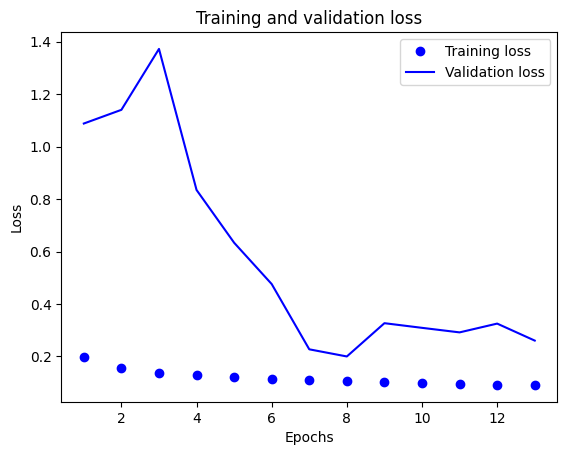

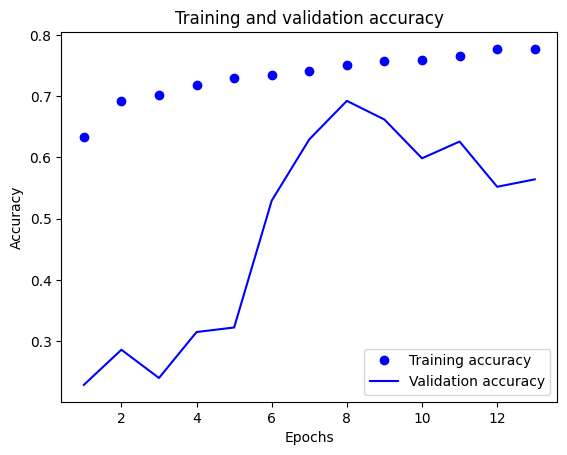

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.8418 - loss: 0.1175 - macro_f1: 0.2952
Model 1 - Test Accuracy : 0.8418
Model 1 - Test Loss     : 0.1175
Model 1 - Test Macro F1 : 0.2952


In [13]:
backend.clear_session()
model1 = Base_DamageCNN_F1()

history1 = model1.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1', patience=5,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5,
                          patience=3, verbose=1, mode='max')
    ]
)

plot_history(history1)

results     = model1.evaluate(test_generator, steps=len(test_generator))
test_loss1  = results[0]
test_acc1   = results[1]
test_f1_1   = results[2]

print(f'Model 1 - Test Accuracy : {test_acc1:.4f}')
print(f'Model 1 - Test Loss     : {test_loss1:.4f}')
print(f'Model 1 - Test Macro F1 : {test_f1_1:.4f}')

model1.save(os.path.join(base_path, 'model1_focal_f1.keras'))

In [14]:
test_generator.reset()
preds        = model1.predict(test_generator,
                               steps=len(test_generator), verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes[:len(pred_classes)]
class_names  = list(test_generator.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, pred_classes,
                             target_names=class_names))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(true_classes, pred_classes), 4))

print("\nPer Class Accuracy:")
for i, cls in enumerate(class_names):
    mask    = np.array(true_classes) == i
    cls_acc = np.mean(np.array(pred_classes)[mask] == i)
    print(f"  {cls}: {int(np.sum(mask))} samples - Accuracy: {cls_acc:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step
Classification Report:
                    precision    recall  f1-score   support

            Intact       0.96      0.88      0.92      1001
      Major_Damage       0.10      0.14      0.11        22
Structural_Failure       0.01      0.04      0.02        26

          accuracy                           0.84      1049
         macro avg       0.36      0.35      0.35      1049
      weighted avg       0.92      0.84      0.88      1049

Balanced Accuracy: 0.351

Per Class Accuracy:
  Intact: 1001 samples - Accuracy: 0.8781
  Major_Damage: 22 samples - Accuracy: 0.1364
  Structural_Failure: 26 samples - Accuracy: 0.0385


## **Evaluation Results**

This is the first time in the entire project where the model detects anything other than Intact. 

Major Damage F1 of 0.11 and Structural Failure F1 of 0.02 are both very low but this is the first non-zero result after all the previous strategies failed completely. The Balanced Accuracy score is 0.351.

The Macro F1 of 0.2952 is still below the baseline of 0.33 because the Intact F1 dropped while minority class F1 is still low, but the model is no longer ignoring damaged buildings entirely. This confirms that the combination of Focal Loss + Balanced Generator + Macro F1 monitoring is the right direction.